Optimisation de l'entrainement pour `focus` 
This is the same function as used in `10_Transfer_learning_what_networks.ipynb`
> ... TODO ... # TODO test without circular padding, with Adam, with no warmstart 

    model = torchvision.models.resnet18(weights=None)

# optimize meta-parameters

In [1]:
%ls -ltr cached_data/34*

-rw-r--r--@ 1 laurentperrinet  staff  262144  5 août  21:20 cached_data/34_optuna.sqlite3


In [2]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
import retinoto_py as fovea

# subset_factor, num_epochs = 50, 20
subset_factor, num_epochs = 1, 1
subset_factor, num_epochs = 50, 1
subset_factor, num_epochs = 10, 1
args_dict = dict(do_fovea=True, do_augment=True, num_epochs=num_epochs, subset_factor=subset_factor, verbose=False)
args = fovea.Params(**args_dict)

In [4]:
%ls -ltr cached_data/32*

-rw-r-----@ 1 laurentperrinet  staff       32828 13 avr.  10:04 cached_data/32_fovea_model_name=convnext_base_dataset=bbox_checkpoint.json
-rw-r-----@ 1 laurentperrinet  staff  1063578969 13 avr.  10:04 cached_data/32_fovea_model_name=convnext_base_dataset=bbox_checkpoint.pth
-rw-r-----@ 1 laurentperrinet  staff  1063554241  6 mai   23:33 cached_data/32_fovea_model_name=convnext_base_dataset=bbox.pth
-rw-r-----@ 1 laurentperrinet  staff       65070  6 mai   23:33 cached_data/32_fovea_model_name=convnext_base_dataset=bbox.json


In [5]:
%ls -ltr cached_data/33*

-rw-r--r--@ 1 laurentperrinet  staff  225 19 mai   12:00 cached_data/33_model_comparison.json


In [6]:
dataset = "bbox"
# TRAIN_DATA_DIR = args.DATAROOT / f"Imagenet_{dataset}" / "train"
# VAL_DATA_DIR = args.DATAROOT / f"Imagenet_{dataset}" / "val"

In [7]:
# model_filename = None # do not use resumed net
name = f"32_fovea_model_name={args.model_name}_dataset={dataset}"
if True: #  False: #loading current checkpoint
    model_filename = args.data_cache / f"{name}.pth"
    json_filename = args.data_cache / f"{name}.json"
else: 
    model_filename, json_filename = None, None
# model = fovea.load_model(args, model_filename=model_filename)
# model_filename

In [8]:
if json_filename is not None:
    df_train = fovea.pd.read_json(json_filename)
    accuracy = df_train.tail(1)['acc_val'].item()
    args_dict['num_epochs'] = df_train.tail(1)['epoch'].item() + 1 + 1
    print(f"{accuracy=:.4f} and starting {args_dict['num_epochs']=} ")
else:
    df_train = None
args = fovea.Params(**args_dict)
args

accuracy=0.7999 and starting args_dict['num_epochs']=341 


Params(batch_size=32, num_workers=4, prefetch_factor=0, image_size=224, grid_size_ecc=161, grid_size_ang=309, do_mask=False, do_fovea=True, use_hexagonal_grid=True, rs_min=-3.5, rs_max=0.7, angle_start=-2.0943951023931953, angle_margin=0.30500899549415467, mode='bilinear', padding_mode='zeros', model_name='convnext_base', num_epochs=341, subset_factor=10, optimizer_name='rmsprop', loss_name='CrossEntropyLoss', base_lr=1e-06, final_lr=1e-09, num_warmup_epochs=20, delta1=0.3, delta2=0.002, weight_decay=0.0001, label_smoothing=0.0005, do_full_training=True, do_augment=True, augment_proba=0.1, stochastic_depth_prob=0.6, seed=1998, shuffle=True, verbose=False)

In [9]:
def objective(trial):
    args = fovea.Params(**args_dict)
    if json_filename is not None:
        df_train = fovea.pd.read_json(json_filename)
    else:
        df_train = None

    # args.batch_size = trial.suggest_int('batch_size', 64, 1024, log=True)
    # args.grid_size_ang = trial.suggest_int('grid_size_ang', 128, 400)
    # args.grid_size_ecc = trial.suggest_int('grid_size_ecc', 128, 400)

    # keep the number of pixels the same but change the grid shape
    # args.grid_size_ang = trial.suggest_int('grid_size_ang', 64, 224**2//64)
    # args.grid_size_ang = trial.suggest_int('grid_size_ang', 220, 380)
    # args.grid_size_ang = trial.suggest_int('grid_size_ang', 280, 320)
    # # args.grid_size_ang = trial.suggest_categorical('grid_size_ang', [196, 224, 256, 225, 223,  226, 222, 339, 290, 346, 173, 221, 227, 190, 176, 152, 220, 264, 240, 330, 304, 209, 165, 228, 285, 229, 219, 295, 170, 199, 252, 274, 183, 203, 247, 230, 218, 277, 181, 185, 271, 302, 166, 151, 332, 241, 208, 217, 341, 231])
    # # args.loss_name = trial.suggest_categorical('loss_name', ['CrossEntropyLoss', 'BCEWithLogitsLoss', 'NegLogitLoss'])
    # args.grid_size_ecc = 224**2//args.grid_size_ang

    # args.rs_min = trial.suggest_float('rs_min', -3.6, -2., log=False)
    # args.rs_max = trial.suggest_float('rs_max', .25, .35, log=False)
    # args.angle_start = trial.suggest_float('angle_start', -7*fovea.np.pi/4, fovea.np.pi/4, log=False)
    # args.angle_margin = trial.suggest_float('angle_margin', 0, fovea.np.pi/8, log=False)
    # args.use_hexagonal_grid = trial.suggest_categorical('use_hexagonal_grid', [True, False])

    # the following needs a fresh start
    # optimizer_names = ['adamw', 'adam', 'rmsprop', 'adadelta', 'sgd'] # 
    # args.optimizer_name = trial.suggest_categorical('optimizer_name', optimizer_names)
    # args.loss_name = trial.suggest_categorical('loss_name', ['CrossEntropyLoss', 'BCEWithLogitsLoss', 'NegLogitLoss'])

    # args.augment_proba = trial.suggest_float("augment_proba", 0, 0.6)

    # # scale = 100
    scale = 10
    scale = 4
    # args.base_lr = trial.suggest_float('base_lr', args.base_lr / scale, args.base_lr * scale, log=True)
    args.final_lr = trial.suggest_float('final_lr', args.final_lr / scale, args.final_lr * scale, log=True)

    if args.weight_decay > 0:
        args.weight_decay = trial.suggest_float(
            "weight_decay", args.weight_decay / scale, args.weight_decay * scale, log=True
        )

    close_to_one = 1 - 1.e-3
    args.label_smoothing = trial.suggest_float(
        "label_smoothing", args.label_smoothing / scale, min(args.label_smoothing * scale, close_to_one), log=True
    )
    args.stochastic_depth_prob = trial.suggest_float("stochastic_depth_prob", 0.20, 0.8, log=False)

    # scale = 4
    args.delta1 = trial.suggest_float('delta1', args.delta1 / scale, min((args.delta1 * scale, close_to_one)), log=True)
    if args.delta2>0: args.delta2 = trial.suggest_float('delta2', args.delta2 / scale, min((args.delta2 * scale, close_to_one)), log=True)

    # get the architecture of the network, train and get accuracy on the validation set
    # train_dataset = fovea.get_dataset(args, TRAIN_DATA_DIR, do_augment=True)
    # train_loader = fovea.get_loader(args, train_dataset)
    # val_dataset = fovea.get_dataset(args, VAL_DATA_DIR, do_augment=False)
    # val_loader = fovea.get_loader(args, val_dataset)
    train_loader = fovea.get_train_loader(args, dataset)
    val_loader = fovea.get_val_loader(args, dataset)
    _, df_train = fovea.train_model(
        args,
        train_loader=train_loader,
        val_loader=val_loader, df_train=df_train, 
        model_filename=model_filename,
        json_filename=None, # in order to not overwrite the existing json file
    )
    accuracy = df_train.tail(1)['acc_val'].item()

    return accuracy


# total_trials = 500
total_trials = 120
total_trials = 70
# 3. Create a study object and optimize the objective function.
study = optuna.create_study(
    storage="sqlite:///cached_data/34_optuna.sqlite3",
    sampler=optuna.samplers.TPESampler(multivariate=True),
    # sampler=optuna.samplers.TPESampler(),
    direction="maximize",
    load_if_exists=True,
    study_name="34_optuna",
)
print(f"Starting optimization with params: {args} on {max(total_trials - len(study.trials), 0)} trials - {len(study.trials)}")
study.optimize(objective, n_trials=max((total_trials - len(study.trials), 0)), n_jobs=1, show_progress_bar=True)

print(50 * "-.")
print("Best params: ", study.best_params)
print("Best value: ", study.best_value)
print("Best Trial params: ", study.best_trial.params)
# print("Trials: ", study.trials)

/var/folders/3s/q2x8bxzj43g4rdvb2wjt67640000gq/T/ipykernel_7627/891253916.py:79: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(multivariate=True),


Starting optimization with params: Params(batch_size=32, num_workers=4, prefetch_factor=0, image_size=224, grid_size_ecc=161, grid_size_ang=309, do_mask=False, do_fovea=True, use_hexagonal_grid=True, rs_min=-3.5, rs_max=0.7, angle_start=-2.0943951023931953, angle_margin=0.30500899549415467, mode='bilinear', padding_mode='zeros', model_name='convnext_base', num_epochs=341, subset_factor=10, optimizer_name='rmsprop', loss_name='CrossEntropyLoss', base_lr=1e-06, final_lr=1e-09, num_warmup_epochs=20, delta1=0.3, delta2=0.002, weight_decay=0.0001, label_smoothing=0.0005, do_full_training=True, do_augment=True, augment_proba=0.1, stochastic_depth_prob=0.6, seed=1998, shuffle=True, verbose=False) on 0 trials - 70
-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.
Best params:  {'final_lr': 1.1672254921331988e-09, 'weight_decay': 0.00011061993595891366, 'label_smoothing': 0.0007011704518258711, 'stochastic_depth_prob': 0.41777960447655393, 'del

In [10]:
study = optuna.load_study(storage="sqlite:///cached_data/34_optuna.sqlite3", study_name="34_optuna")

In [11]:
len(study.trials)

70

In [12]:
import numpy as np
from collections import Counter

# --------------------------------------------------------------
# 2. Best Value and Confidence Intervals / Categorical Counts
# --------------------------------------------------------------
print("\n[2] BEST VALUES WITH CONFIDENCE INTERVALS:")

if not study.trials:
    print("No trials found.")
else:
    best_trial = study.best_trial
    print(f"\nBest Objective Value: {best_trial.value:.5f}")

    # ------------------------------------------------------------------
    # Gather only the *completed* trials (i.e. those that have a value)
    # ------------------------------------------------------------------
    completed_trials = [
        t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE
    ]

    if not completed_trials:
        print("No completed trials available.")
    else:
        # --------------------------------------------------------------
        # 10 % best trials → we use them to estimate the CI
        # --------------------------------------------------------------
        top_trials = sorted(
            completed_trials, key=lambda t: t.value, reverse=True
        )[: max(1, len(completed_trials) // 10)]

        # Build a dict: param name → list of that param’s values in the top trials
        params_all = {pname: [] for pname in best_trial.params}
        for trial in top_trials:
            for pname in params_all:
                if pname in trial.params:
                    params_all[pname].append(trial.params[pname])

        print("\nEstimated Confidence Intervals (Top 10% Trials) / "
              "Categorical Counts:")
        for pname in best_trial.params:
            vals = params_all.get(pname, [])
            if not vals:
                print(f"{pname:<30}: No data")
                continue

            # --------------------------------------------------------------
            # Try to treat the values as *numeric*.
            # If **any** conversion fails, fall back to the categorical path.
            # --------------------------------------------------------------
            try:
                # `float` works for int/np.float64 etc.; bool is also convertible.
                # We *exclude* booleans from the numeric path because the user
                # wants a simple count for them.
                if any(isinstance(v, bool) for v in vals):
                    raise ValueError("booleans are considered categorical")

                vals_float = np.asarray(vals, dtype=float)   # may raise ValueError
                # ---------- numeric branch ----------
                low    = np.percentile(vals_float, 5)
                high   = np.percentile(vals_float, 95)
                median = np.median(vals_float)

                print(
                    f"{pname:<30}: Best={best_trial.params[pname]:3e}, "
                    f"Median={median:>8.3e}, 90% CI=[{low:>8.3e}, {high:>8.3e}]"
                )
            except Exception:       # <-- non‑numeric, bool, or mixed types
                # ---------- categorical branch ----------
                counter = Counter(vals)
                total   = sum(counter.values())
                # Show the *most common* 5 categories (or all if <5)
                common = counter.most_common(5)

                cat_parts = [
                    f"{cat!r}: {cnt} ({cnt/total:.1%})" for cat, cnt in common
                ]
                cat_str = "; ".join(cat_parts)

                print(
                    f"{pname:<30}: Categorical counts → {cat_str}"
                )


[2] BEST VALUES WITH CONFIDENCE INTERVALS:

Best Objective Value: 0.79700

Estimated Confidence Intervals (Top 10% Trials) / Categorical Counts:
final_lr                      : Best=1.167225e-09, Median=4.402e-09, 90% CI=[1.472e-09, 2.707e-08]
weight_decay                  : Best=1.106199e-04, Median=3.478e-04, 90% CI=[1.284e-04, 5.721e-04]
label_smoothing               : Best=7.011705e-04, Median=3.135e-04, 90% CI=[9.725e-05, 7.904e-04]
stochastic_depth_prob         : Best=4.177796e-01, Median=4.269e-01, 90% CI=[3.238e-01, 5.731e-01]
delta1                        : Best=3.237110e-01, Median=5.775e-01, 90% CI=[2.358e-01, 8.809e-01]
delta2                        : Best=1.913069e-03, Median=6.237e-03, 90% CI=[1.294e-03, 6.437e-02]


/var/folders/3s/q2x8bxzj43g4rdvb2wjt67640000gq/T/ipykernel_7627/2942231285.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_param_importances(study)


<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

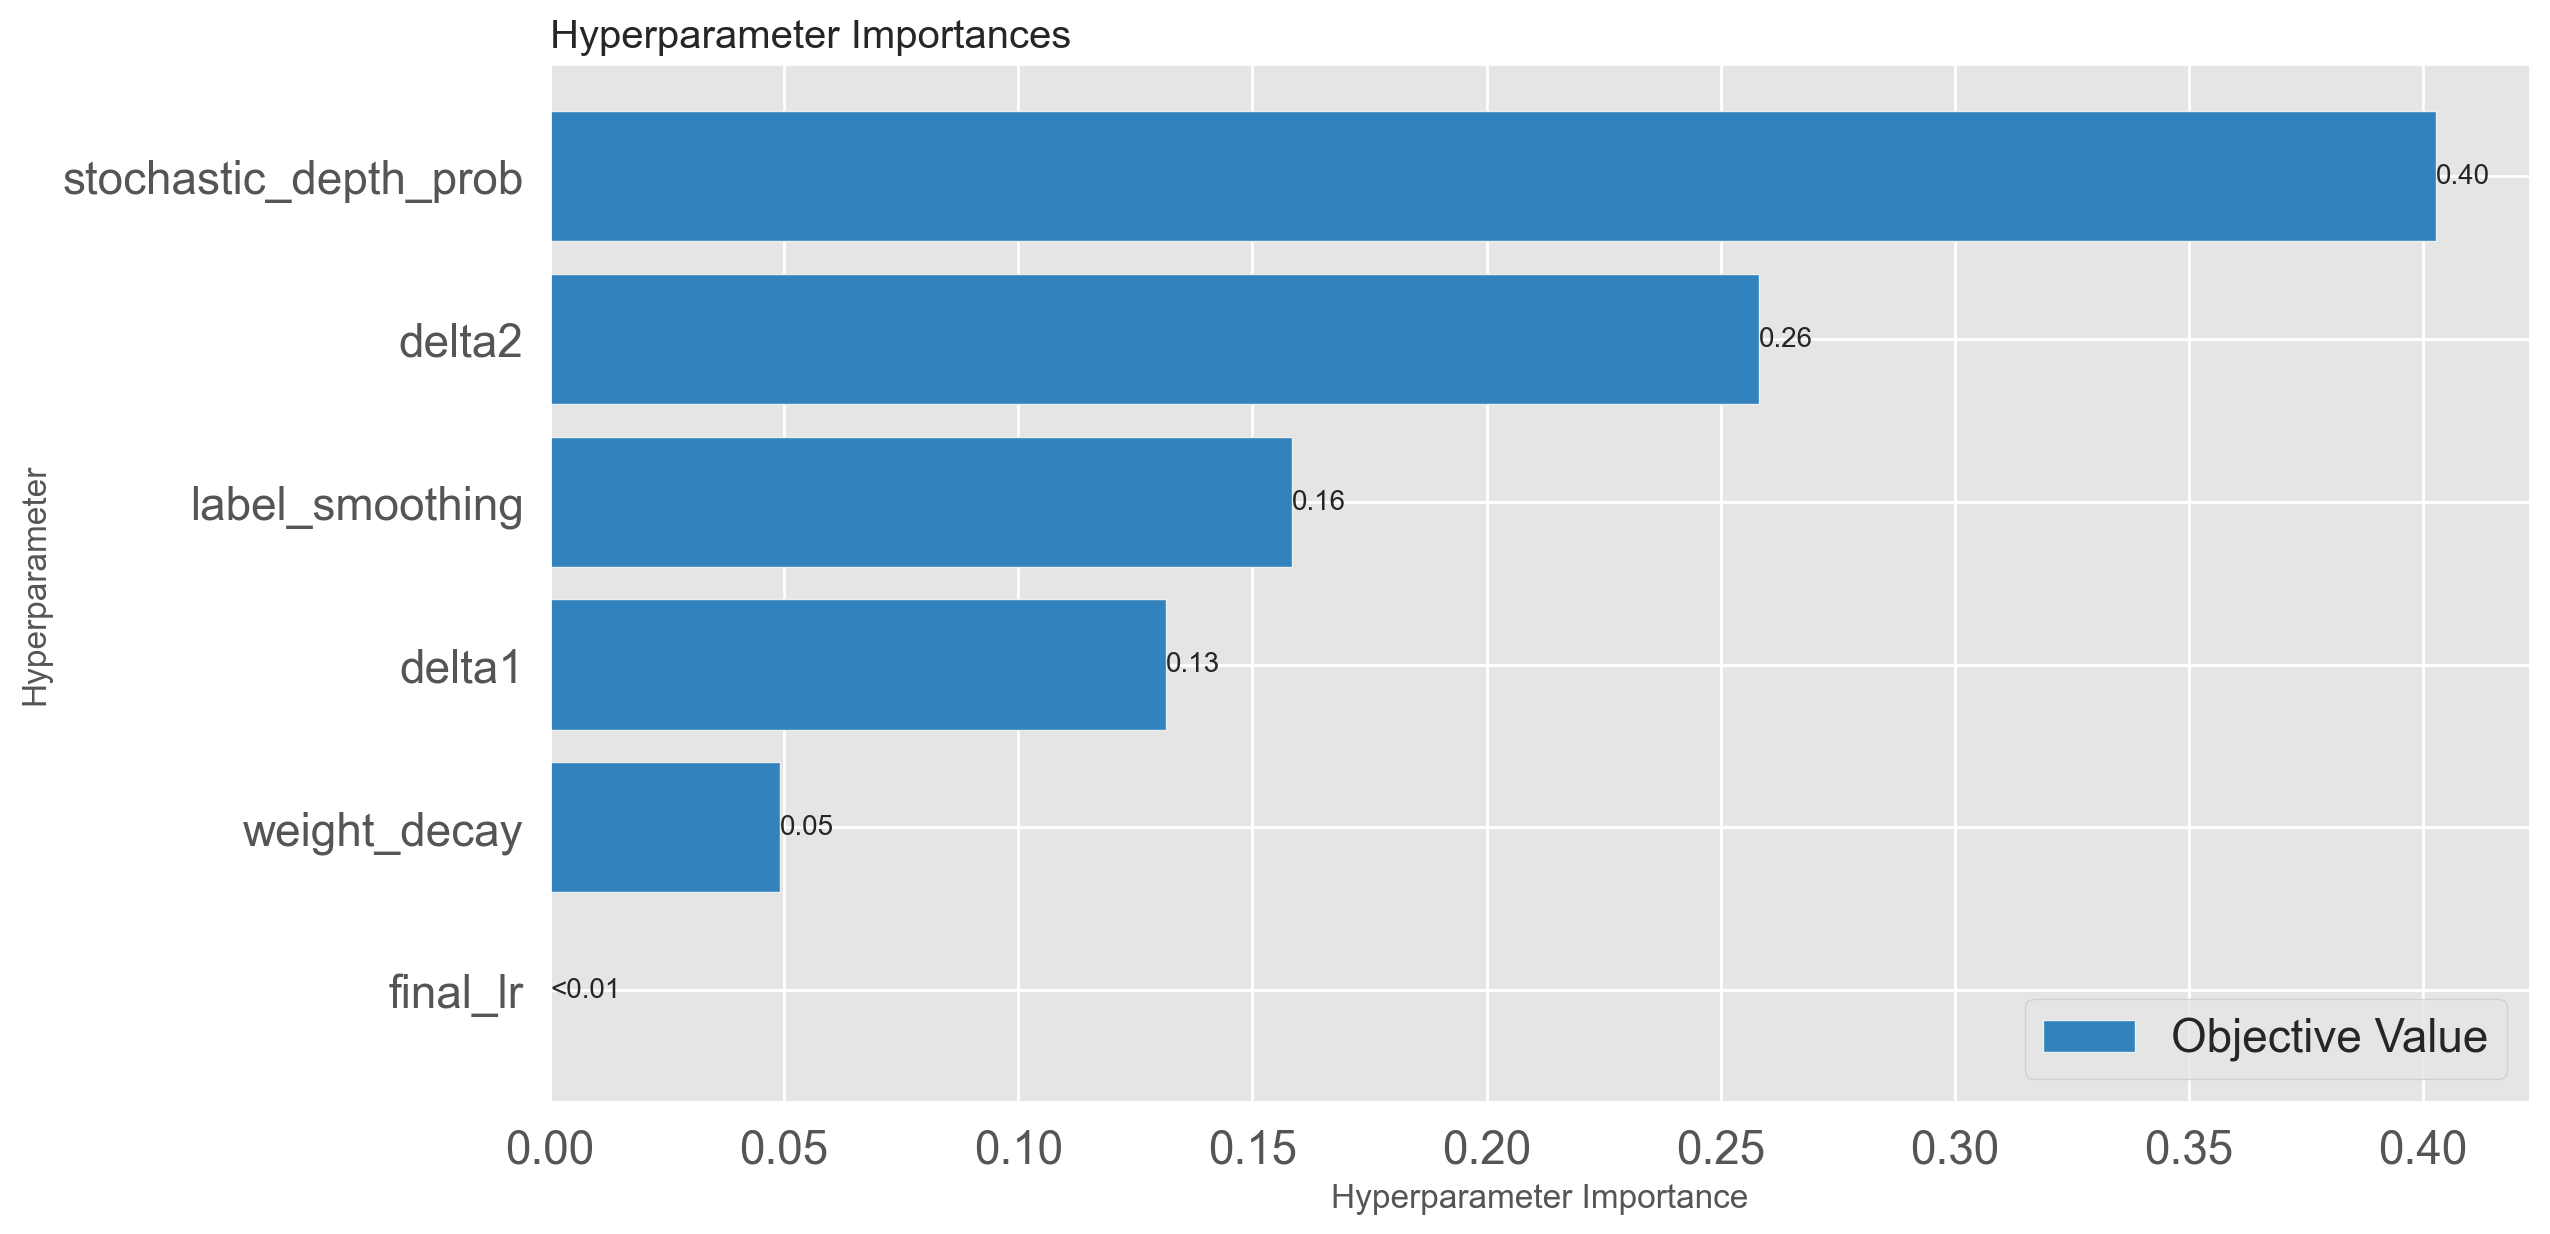

In [13]:
import optuna.visualization.matplotlib as vis
vis.plot_param_importances(study)

In [14]:
params

NameError: name 'params' is not defined

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import numpy as np
import pandas as pd

# Charger l'étude
params = sorted({k for t in study.trials for k in t.params})

fig, axes = plt.subplots(len(params), 1, figsize=(15, 8 * len(params)), sharey=True)

for ax, pname in zip(axes, params):
    xs = [t.params[pname] for t in study.trials if pname in t.params]
    ys = [t.value for t in study.trials if pname in t.params]

    df = pd.DataFrame({"x": xs, "y": ys})
    df = df.dropna(subset=["y"])
    # **Drop the 75% worst trials**
    cutoff = np.percentile(df["y"], 50)
    df_best = df[df["y"] > cutoff]           

    # Déterminer si le paramètre est numérique (et non catégoriel)
    is_numeric = pd.api.types.is_numeric_dtype(df_best["x"])
    if is_numeric:
        # Si numérique, vérifier s'il y a assez de valeurs distinctes pour LOWESS
        if len(df_best["x"].unique()) > 1:
            sns.regplot(
                x="x", y="y", data=df_best, ax=ax, lowess=True, color="red",
                line_kws={"lw": 2, "label": "Tendance (LOWESS)"}, scatter=False
            )
    else:
        # Pour les catégories, convertir en chaîne et afficher un boxplot
        df_best["x"] = df_best["x"].astype(str)
    
    ax.scatter(df_best["x"], df_best["y"], s=20, alpha=0.7, color="blue", label="Trials")

    ax.set_xlabel(pname)
    ax.set_ylabel("Objective")
    # if pname not in ['loss_name', 'optimizer_name', 'rs_min', 'rs_max', 'angle_start', 'angle_margin', 'use_hexagonal_grid']:
    #     ax.set_xscale("log")
plt.tight_layout()
# plt.show()